In [3]:
import numpy as np

# Inputs / Assumptions
# initial value of portfolio (what you start with)
initial_value = 100_000
# investment horizon
years = 10
# mean annual return
expected_return = 0.07
# annual volatility (standard deviation of returns)
volatility = 0.15
# portfolio value you want to reach (goal)
target_value = 200_000
# number of Monte Carlo runs
n_simulations = 10_000
# fixes randomness, so results are reproducible
seed = 42

rng = np.random.default_rng(seed)
print('Setup ready, inputs defined.')

Setup ready, inputs defined.


In [7]:
# converting to log space parameters
mu = expected_return
sigma = volatility

log_mu = np.log(1 + mu) - 0.5 * np.log(1+(sigma**2)/(1 + mu)**2)
log_sigma = np.sqrt(np.log(1+(sigma**2)/ (1 + mu)**2))

growth_factors = np.exp(rng.normal(log_mu, log_sigma, size=(n_simulations, years)))

print('Shape:', growth_factors.shape)
print("\nFirst simulations's 10 growth factors:")
print(growth_factors[0].round(3))
print('\nMin growth factor in whole grid:', growth_factors.min().round(4))
print('Mean implied return:',(growth_factors.mean()-1).round(4))

Shape: (10000, 10)

First simulations's 10 growth factors:
[1.353 1.161 1.001 1.096 0.947 1.164 1.062 0.961 0.939 1.097]

Min growth factor in whole grid: 0.5869
Mean implied return: 0.07


In [10]:
cumulative_growth = np.cumprod(growth_factors, axis = 1)
paths = initial_value * cumulative_growth
start_column = np.full((n_simulations, 1), initial_value)
paths = np.hstack([start_column, paths])

print('Paths shape:', paths.shape)
print("\nFirst simulation's value each year (rounded):")
print(paths[0].round(2))
print(f'\nYear 0 of every path should be {initial_value}:', np.all(paths[:,0]==initial_value))

Paths shape: (10000, 11)

First simulation's value each year (rounded):
[100000.   135261.29 157015.31 157214.49 172379.91 163271.36 189984.7
 201769.03 193845.86 182094.93 199736.95]

Year 0 of every path should be 100000: True


In [14]:
# each simulation's year 10 portfolio value
terminal_values = paths[:, -1]

# portfolios that finished at target value or above
hit_target = terminal_values >= target_value
prob_attainment = hit_target.mean()

# percentiles of final values
p10 = np.percentile(terminal_values, 10)
p50 = np.percentile(terminal_values, 50)
p90 = np.percentile(terminal_values, 90)

print(f'Target: ${target_value}')
print(f'Probability of reaching target: {prob_attainment:.1%}')
print(f"P10 (pessimistic):${p10:,.0f}")
print(f"P50 (median):${p50:,.0f}")
print(f"P90 (optimistic):${p90:,.0f}")
print(f"Mean:${terminal_values.mean():,.0f}")

Target: $200000
Probability of reaching target: 39.5%
P10 (pessimistic):$101,829
P50 (median):$176,873
P90 (optimistic):$317,155
Mean:$196,989


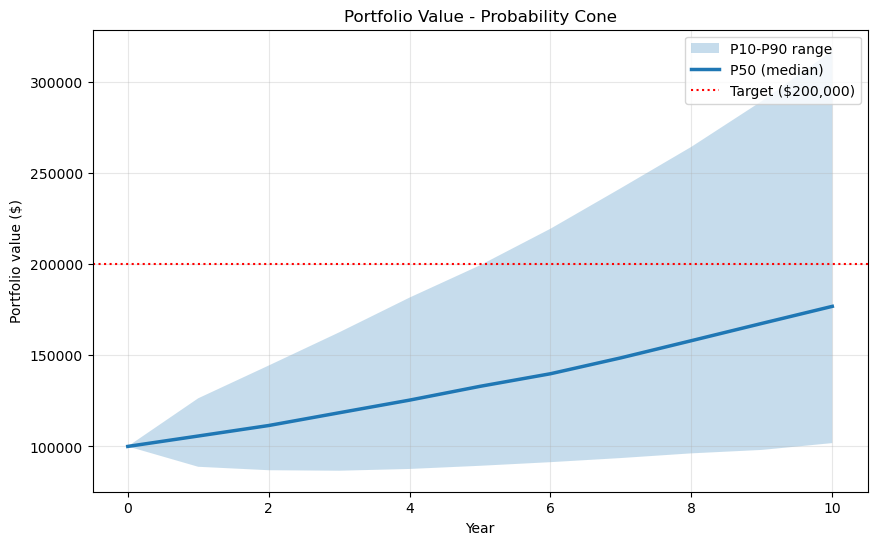

In [18]:
import matplotlib.pyplot as plt

years_axis = np.arange(years+1)
# percentiles computed every year
cone_p10 = np.percentile(paths, 10, axis=0) 
cone_p50 = np.percentile(paths, 50, axis=0)
cone_p90 = np.percentile(paths, 90, axis=0)

fig, ax = plt.subplots(figsize=(10,6))

# adding shading band between p10 and p90
ax.fill_between(years_axis, cone_p10, cone_p90, alpha=0.25, label='P10-P90 range')

# adding median line
ax.plot(years_axis, cone_p50, linewidth=2.5, label='P50 (median)')

# target reference line
ax.axhline(target_value, color='red', linestyle=':', label=f"Target (${target_value:,.0f})")

ax.set_title("Portfolio Value - Probability Cone")
ax.set_xlabel("Year")
ax.set_ylabel("Portfolio value ($)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

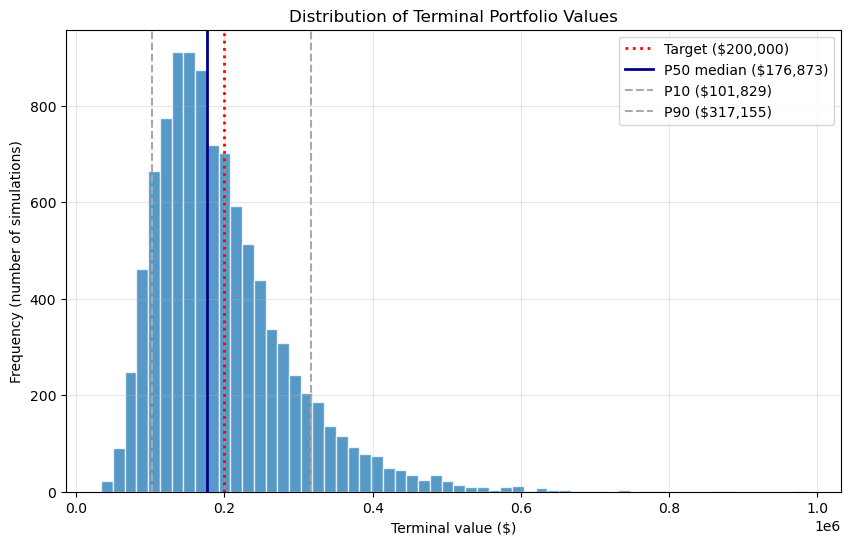

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

# histogram of the 10,000 final values, split into 60 bins
ax.hist(terminal_values, bins=60, alpha=0.75, edgecolor="white")

# mark target and key percentiles.
ax.axvline(target_value, color="red", linestyle=":", linewidth=2, label=f"Target (${target_value:,.0f})")
ax.axvline(p50, color="darkblue", linewidth=2, label=f"P50 median (${p50:,.0f})")
ax.axvline(p10, color="darkgray", linestyle="--", label=f"P10 (${p10:,.0f})")
ax.axvline(p90, color="darkgray", linestyle="--", label=f"P90 (${p90:,.0f})")

ax.set_title("Distribution of Terminal Portfolio Values")
ax.set_xlabel("Terminal value ($)")
ax.set_ylabel("Frequency (number of simulations)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()